# Notebook 01 — OCR with Tesseract on a Synthetic Citation Line

Companion to `01-ocr-fundamentals.md`. We synthesize a small text image containing a normal
sentence plus a **superscript-style citation marker** (a small digit, shifted above the
baseline — see Chapter 01), run it through `pytesseract` (Tesseract OCR), and inspect the
structured per-word output.

This notebook is designed to run **fully offline**: if `pytesseract` or the Tesseract binary
isn't installed, it falls back to printing what the expected output structure would look
like, rather than failing. That fallback structure is exactly the kind of OCR
word+bounding-box output the Chapter 01 `ocr_words` example is based on, and it's what
Notebook 04's mocked `fake_ocr()` function represents.

> `pip install pytesseract pillow` — and, separately, the Tesseract OCR **binary** itself
> (e.g. `choco install tesseract` on Windows, `apt install tesseract-ocr` on Linux, `brew
> install tesseract` on macOS) needs to be on your PATH for `pytesseract` to actually work.
> Neither is required to run this notebook end to end.


Saved synthetic image to synthetic_citation_line.png


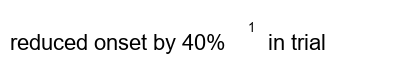

In [1]:
from PIL import Image, ImageDraw, ImageFont

IMG_W, IMG_H = 420, 80
BASELINE_Y = 30


def make_synthetic_citation_image():
    """Builds a small image reading "reduced onset by 40%<sup>1</sup> in trial", where the
    "1" is drawn in a smaller font and shifted above the sentence baseline -- i.e. a
    synthetic superscript citation marker, the exact pattern Chapter 01 describes.
    """
    img = Image.new("RGB", (IMG_W, IMG_H), color="white")
    draw = ImageDraw.Draw(img)
    try:
        font = ImageFont.truetype("arial.ttf", 22)
        font_small = ImageFont.truetype("arial.ttf", 13)
    except OSError:
        font = ImageFont.load_default()
        font_small = ImageFont.load_default()

    draw.text((10, BASELINE_Y), "reduced onset by 40%", fill="black", font=font)
    # superscript "1" -- smaller font, shifted ~10px above the sentence baseline
    draw.text((248, BASELINE_Y - 10), "1", fill="black", font=font_small)
    draw.text((262, BASELINE_Y), " in trial", fill="black", font=font)
    return img


synthetic_image = make_synthetic_citation_image()
out_path = "synthetic_citation_line.png"
synthetic_image.save(out_path)
print(f"Saved synthetic image to {out_path}")
synthetic_image


## Running OCR

We attempt a real `pytesseract.image_to_data()` call, which (when Tesseract is installed)
returns per-word text plus `left/top/width/height` bounding-box fields and a confidence
score — this is the structured, geometry-aware OCR output Chapter 01 describes as the
contract between Stage 1 and Stage 2 of the pipeline.

If the import fails (`pytesseract` not installed) or the call fails (Tesseract binary not on
PATH — the most common issue in a fresh/offline environment), we catch the exception and
print an **illustrative** version of what the structured output would look like instead, so
the notebook always completes successfully.


In [2]:
expected_structure_fallback = [
    {"text": "reduced", "left": 10,  "top": 30, "width": 68, "height": 22, "conf": 91.2},
    {"text": "onset",   "left": 82,  "top": 30, "width": 55, "height": 22, "conf": 90.4},
    {"text": "by",      "left": 141, "top": 30, "width": 24, "height": 22, "conf": 88.7},
    {"text": "40%",     "left": 169, "top": 30, "width": 55, "height": 22, "conf": 85.0},
    {"text": "1",       "left": 248, "top": 20, "width": 10, "height": 13, "conf": 74.3},
    {"text": "in",      "left": 262, "top": 30, "width": 20, "height": 22, "conf": 92.1},
    {"text": "trial",   "left": 286, "top": 30, "width": 44, "height": 22, "conf": 89.6},
]

words = None
used_real_tesseract = False

try:
    import pytesseract
    from pytesseract import Output

    data = pytesseract.image_to_data(synthetic_image, output_type=Output.DICT)
    parsed = []
    for i, text in enumerate(data["text"]):
        if text.strip():
            parsed.append({
                "text": text,
                "left": data["left"][i],
                "top": data["top"][i],
                "width": data["width"][i],
                "height": data["height"][i],
                "conf": float(data["conf"][i]),
            })

    if not parsed:
        raise RuntimeError("Tesseract ran but returned no text -- treating as unavailable")

    words = parsed
    used_real_tesseract = True
    print("pytesseract + Tesseract binary are available -- ran OCR for real.\n")
except Exception as exc:
    words = expected_structure_fallback
    print(f"[fallback] pytesseract/Tesseract not usable here ({type(exc).__name__}: {exc}).")
    print("Falling back to the EXPECTED output structure (illustrative, not a real OCR run):\n")

print(f"used_real_tesseract = {used_real_tesseract}\n")
for w in words:
    print(w)


[fallback] pytesseract/Tesseract not usable here (ModuleNotFoundError: No module named 'pytesseract').
Falling back to the EXPECTED output structure (illustrative, not a real OCR run):

used_real_tesseract = False

{'text': 'reduced', 'left': 10, 'top': 30, 'width': 68, 'height': 22, 'conf': 91.2}
{'text': 'onset', 'left': 82, 'top': 30, 'width': 55, 'height': 22, 'conf': 90.4}
{'text': 'by', 'left': 141, 'top': 30, 'width': 24, 'height': 22, 'conf': 88.7}
{'text': '40%', 'left': 169, 'top': 30, 'width': 55, 'height': 22, 'conf': 85.0}
{'text': '1', 'left': 248, 'top': 20, 'width': 10, 'height': 13, 'conf': 74.3}
{'text': 'in', 'left': 262, 'top': 30, 'width': 20, 'height': 22, 'conf': 92.1}
{'text': 'trial', 'left': 286, 'top': 30, 'width': 44, 'height': 22, 'conf': 89.6}


## Flagging small, elevated candidates (the geometric signal Stage 2 relies on)

Chapter 01's key point: the OCR *text* string alone can't tell you which glyph is a
superscript — you need the **geometry**. Here we do a crude version of the size/position
check by hand, purely to illustrate the signal; the real pipeline hands this job to a
trained YOLO detector (Notebook 02) rather than a hand-tuned threshold like this one (recall
Chapter 01/99's discussion of why a naive heuristic underperforms).


In [3]:
median_height = sorted(w["height"] for w in words)[len(words) // 2]
median_top = sorted(w["top"] for w in words)[len(words) // 2]

print(f"Median glyph height on this line: {median_height}px | median top: {median_top}px\n")

for w in words:
    is_small = w["height"] < 0.75 * median_height
    is_elevated = w["top"] < median_top - 3
    flag = "<-- superscript-shaped candidate" if (is_small and is_elevated) else ""
    print(f'{w["text"]:>10}  h={w["height"]:>3}  top={w["top"]:>3}  {flag}')


Median glyph height on this line: 22px | median top: 30px

   reduced  h= 22  top= 30  
     onset  h= 22  top= 30  
        by  h= 22  top= 30  
       40%  h= 22  top= 30  
         1  h= 13  top= 20  <-- superscript-shaped candidate
        in  h= 22  top= 30  
     trial  h= 22  top= 30  


## Takeaway

Whether or not Tesseract was actually installed in this environment, the shape of the output
is the same: a list of words, each with a bounding box. That's the minimum viable contract
Stage 2 (YOLO, Notebook 02) needs from Stage 1 — it doesn't need the *text* to be right so
much as it needs the *geometry* to be there. See `01-ocr-fundamentals.md` for the full
discussion of why plain OCR text (without this geometry) can't solve superscript detection on
its own, and `04-building-the-sequential-pipeline.md` for how this feeds into Stage 2.
